# Boundary Conditions and Convergence

Use boundary data and resolution changes to test whether wave-equation errors decrease as expected.

Navigation: [Index](../index.ipynb) | Previous: [Method of Lines and Runge-Kutta Methods](method_of_lines_and_rk.ipynb) | Next: [Finite-Difference Playground](finite_difference_playground.ipynb)


## Learning Goals

- Run the wave project at two resolutions.
- Compare diagnostic errors at the same physical time.
- Use error reduction as evidence that the boundary-handled calculation is working.

## Words for This Notebook

- **Boundary condition:** a rule for what happens at the edge of the grid.
- **Resolution:** how many grid points are used to represent the domain.
- **Convergence factor:** the multiplier used to refine the grid.
- **Diagnostic row:** one line of output numbers written by the simulation.

Use the code cells actively: first predict what should happen, then run the cell, then explain the output in plain language. This predict-run-explain pattern keeps the physics idea connected to the programming details.


## Generate, Run, and Compare Diagnostics
The Cartesian wave project uses periodic boundary handling in its compact test case. Running with convergence factor 2 refines the grid and should reduce the diagnostic error.

## Import Boundary-Test Execution Helpers

These standard-library tools run commands, manage temporary project directories, and clean command output.

If you are new to Python, do not study this helper cell line by line on a first pass. Its job is practical: run terminal commands, shorten long command output, and stop with a clear message if a required tool is missing. Focus first on the cells that generate, inspect, build, run, and interpret the physics project.


In [1]:
from pathlib import Path
import re, shutil, subprocess, sys, tempfile


def clean_command_output(text):
    cleaned = re.sub(r"\x1b\[[0-?]*[ -/]*[@-~]", "", text or "")
    return cleaned.replace(str(WORKSPACE), "<workspace>")


def run_command(args, cwd, timeout):
    try:
        result = subprocess.run(
            args,
            cwd=cwd,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            check=True,
            timeout=timeout,
        )
    except FileNotFoundError as exc:
        raise RuntimeError(f"Required command is missing: {args[0]}") from exc
    except subprocess.CalledProcessError as exc:
        print(clean_command_output(exc.stdout))
        raise RuntimeError(f"Command failed: {' '.join(map(str, args))}") from exc
    return clean_command_output(result.stdout)


def require_toolchain():
    if shutil.which("make") is None:
        raise RuntimeError(
            "This notebook requires make to build the generated project."
        )
    if not any(shutil.which(name) for name in ["cc", "gcc", "clang"]):
        raise RuntimeError(
            "This notebook requires a C compiler such as cc, gcc, or clang."
        )


## Create a Boundary-Test Workspace

The workspace keeps generated files separate from the tutorial source tree.


In [2]:
PROJECT_NAME = "wave_equation_cartesian"
workspace_manager = tempfile.TemporaryDirectory(
    prefix="nrpy_tutorial_cartesian_", dir=Path.cwd()
)
WORKSPACE = Path(workspace_manager.name)
PROJECT_DIR = WORKSPACE / "project" / PROJECT_NAME


## Generate the Boundary-Test Project

This command invokes the same module a learner can run from a terminal and then verifies that the project directory exists.


In [3]:
command = [sys.executable, "-m", "nrpy.examples.wave_equation_cartesian"]
print("generator command: python -m nrpy.examples.wave_equation_cartesian")
output = run_command(command, WORKSPACE, timeout=300)
for line in output.splitlines():
    if line.strip():
        print(line.rstrip())
if not PROJECT_DIR.is_dir():
    raise FileNotFoundError(PROJECT_DIR)
print("project path: project/wave_equation_cartesian")


generator command: python -m nrpy.examples.wave_equation_cartesian


Finished! Now go into project/wave_equation_cartesian and type `make` to build, then ./wave_equation_cartesian to run.
    Parameter file can be found in wave_equation_cartesian.par
project path: project/wave_equation_cartesian


## Shorten the Boundary-Test Runtime

Only runtime values are changed so the notebook run finishes quickly.


In [4]:
parfile = PROJECT_DIR / "wave_equation_cartesian.par"
par_text = parfile.read_text(encoding="utf-8")
par_text = par_text.replace("t_final = 8.0", "t_final = 0.3125")
par_text = par_text.replace(
    "diagnostics_output_every = 0.2", "diagnostics_output_every = 0.15625"
)
par_text = par_text.replace(
    "output_progress_every = 1", "output_progress_every = 1000000"
)
parfile.write_text(par_text, encoding="utf-8")
print("--- runtime wave_equation_cartesian.par ---")
print(parfile.read_text(encoding="utf-8", errors="replace"))


--- runtime wave_equation_cartesian.par ---
#### wave_equation_cartesian BH@H parameter file. NOTE: only commondata CodeParameters appear here ###
###########################
###########################
### Module: __main__
convergence_factor = 1.0        # (REAL)
diagnostics_output_every = 0.15625  # (REAL)
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData
sigma = 3.0                     # (REAL)
wavespeed = 1.0                 # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.MoLtimestepping.register_all
CFL_FACTOR = 0.5                # (REAL)
t_final = 0.3125                   # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.diagnostics.progress_indicator
output_progress_every = 1000000       # (int)



## Build the Boundary-Test Executable

The build step compiles generated C after checking that external build tools are available.


In [5]:
require_toolchain()
build_output = run_command(["make", "-j2"], PROJECT_DIR, timeout=300)
print("build completed")
print("compiler output line count:", len(build_output.splitlines()))


build completed
compiler output line count: 16


## Run the Coarse Boundary Test

The default run supplies the coarse diagnostic comparison.


In [6]:
default_output = run_command([f"./{PROJECT_NAME}"], PROJECT_DIR, timeout=90)
print("default run completed")
for line in default_output.splitlines()[:8]:
    if line.strip():
        print(line.rstrip())


default run completed
It: 0 t=0.000 / 0.3 = 0.00% dt=1/6.4 | t/h=0.00 ETA 0h00m00s


## Run the Refined Boundary Test

The convergence-factor run uses the same executable with a refined grid.


In [7]:
refined_output = run_command([f"./{PROJECT_NAME}", "2.0"], PROJECT_DIR, timeout=90)
print("refined run completed")
for line in refined_output.splitlines()[:8]:
    if line.strip():
        print(line.rstrip())


refined run completed


It: 0 t=0.000 / 0.3 = 0.00% dt=1/12.8 | t/h=0.00 ETA 0h00m00s


## Load Diagnostic Rows

The diagnostic rows provide the numerical evidence used for interpretation.


In [8]:
diagnostic_rows = {}
for diagnostic in sorted(PROJECT_DIR.glob("out0d-conv_factor*.txt")):
    rows = [
        [float(value) for value in line.split()]
        for line in diagnostic.read_text(
            encoding="utf-8", errors="replace"
        ).splitlines()
        if line.strip()
    ]
    diagnostic_rows[diagnostic.name] = rows
    print(diagnostic.name, "rows:", len(rows), "last row:", rows[-1])


out0d-conv_factor1.00.txt rows: 2 last row: [0.15625, 4.061498e-08, 2.140944e-05, 3.983805, 3.983805]
out0d-conv_factor2.00.txt rows: 2 last row: [0.15625, 2.797348e-09, 1.349218e-06, 3.989851, 3.989851]


## Plot Boundary-Test Error Histories

A convergence comparison is easier to trust when the whole error history is visible. The refined run should stay below the coarse run at matching times.

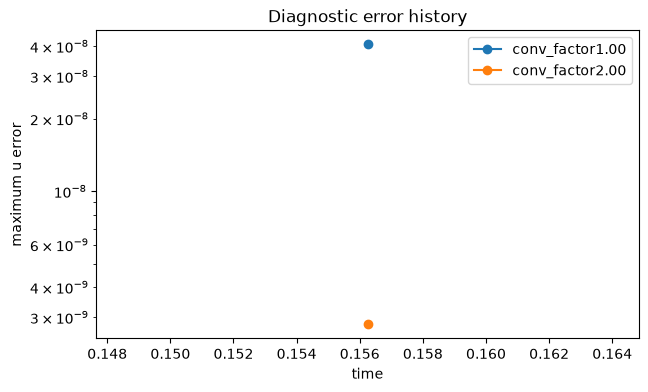

In [9]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 4))
for name, rows in sorted(diagnostic_rows.items()):
    positive_rows = [row for row in rows if row[1] > 0.0]
    times = [row[0] for row in positive_rows]
    errors = [row[1] for row in positive_rows]
    label = name.replace("out0d-", "").replace(".txt", "")
    plt.plot(times, errors, marker="o", label=label)
plt.yscale("log")
plt.xlabel("time")
plt.ylabel("maximum u error")
plt.title("Diagnostic error history")
plt.legend()
plt.show()

## Compare Errors at Matching Time

The diagnostic rows provide the numerical evidence used for interpretation.


In [10]:
coarse_name = "out0d-conv_factor1.00.txt"
fine_name = "out0d-conv_factor2.00.txt"
coarse_times = {
    round(row[0], 12) for row in diagnostic_rows[coarse_name] if row[0] > 0.0
}
fine_times = {round(row[0], 12) for row in diagnostic_rows[fine_name] if row[0] > 0.0}
comparison_time = max(coarse_times.intersection(fine_times))
coarse_row = next(
    row for row in diagnostic_rows[coarse_name] if round(row[0], 12) == comparison_time
)
fine_row = next(
    row for row in diagnostic_rows[fine_name] if round(row[0], 12) == comparison_time
)
coarse_error = coarse_row[1]
fine_error = fine_row[1]
print("comparison time:", f"{comparison_time:.6e}")
print("uu error coarse:", f"{coarse_error:.6e}")
print("uu error fine:", f"{fine_error:.6e}")
print("uu error ratio coarse/fine:", coarse_error / fine_error)
if fine_error >= coarse_error:
    raise RuntimeError("Expected the refined run to reduce the uu error.")


comparison time: 1.562500e-01
uu error coarse: 4.061498e-08
uu error fine: 2.797348e-09
uu error ratio coarse/fine: 14.51910166343265


The comparison uses diagnostic rows at the same physical time. The smaller refined-grid error is the evidence that the boundary-handled finite-difference run is converging.


## Learning Check

Before comparing errors, predict which diagnostic file should correspond to the finer run. Then check whether the error is smaller at the same time.


## Continue to the Finite-Difference Playground
- [Finite-Difference Playground](finite_difference_playground.ipynb)
- [Curvilinear Boundary Conditions](../4-curvilinear/curvilinear_boundary_conditions.ipynb)
- [Start-to-Finish Cartesian Wave Project](../3-wave_equation/start_to_finish_wave_cartesian.ipynb)
